# 03 — Synthetic local-volatility surfaces and option data

Synthetic experiments are essential because the true local-volatility surface
is known.

The workflow in this notebook is

$$
\sigma_{\mathrm{true}}(x,T)
\longrightarrow
C_{\mathrm{true}}(K,T)
\longrightarrow
C_{\mathrm{observed}}(K,T).
$$

The first arrow uses the PDE pricer from Stage 2. The second arrow adds
controlled quote noise.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: /mnt/data/dupire_audit/dupire_local_vol_project


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.data.synthetic_data import (
    generate_synthetic_option_data,
    save_synthetic_option_data,
)
from src.surfaces.synthetic_surfaces import (
    bump_surface,
    constant_surface,
    smile_surface,
)


## 1. Surface grid used only for visualisation

The true local-volatility surfaces are defined in log-moneyness:

$$
x=\log\left(\frac{K}{F(T)}\right).
$$

The arrays below create a fine grid so that we can plot the surfaces smoothly.
This is not yet the sparse option-quote grid.


In [3]:
x_plot = np.linspace(-0.40, 0.40, 81)
maturity_plot = np.linspace(0.05, 2.00, 60)

x_mesh, maturity_mesh = np.meshgrid(
    x_plot,
    maturity_plot,
)

print("Visualisation-grid shape:", x_mesh.shape)


Visualisation-grid shape: (60, 81)


## 2. Constant surface

The simplest test surface is

$$
\sigma_{\mathrm{true}}(x,T)=0.20.
$$

This surface is mainly a unit test because its option prices should agree with
Black–Scholes.


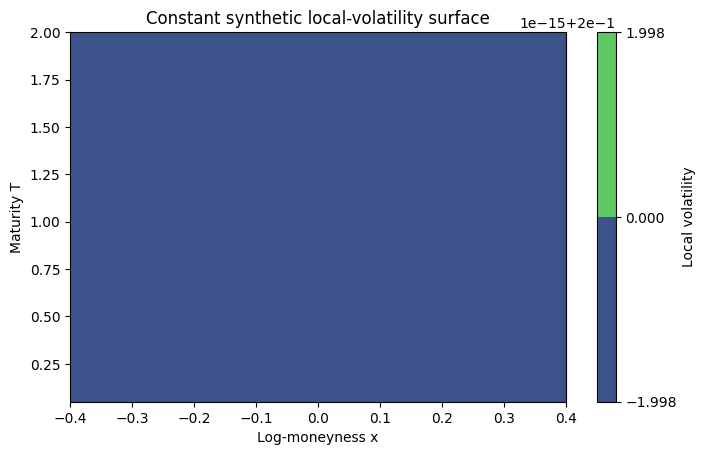

In [4]:
constant_values = constant_surface(
    x_mesh,
    maturity_mesh,
)

plt.figure(figsize=(8, 4.8))
contour = plt.contourf(
    x_plot,
    maturity_plot,
    constant_values,
    levels=20,
)
plt.colorbar(contour, label="Local volatility")
plt.xlabel("Log-moneyness x")
plt.ylabel("Maturity T")
plt.title("Constant synthetic local-volatility surface")
plt.show()


## 3. Smile surface

The smile surface is

$$
\sigma_{\mathrm{true}}(x,T)
=
0.20
+
0.08x^2
+
0.03e^{-3T}.
$$

The \(x^2\) term raises volatility in both wings. The exponential term makes
short-maturity volatility slightly higher.


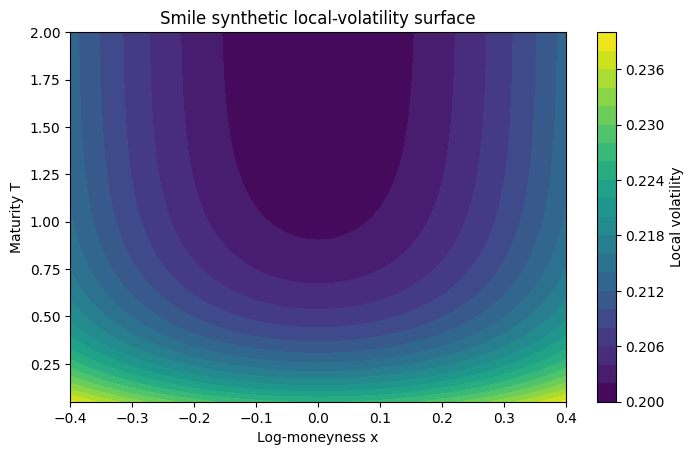

Smile range: 0.2001 to 0.2386


In [5]:
smile_values = smile_surface(
    x_mesh,
    maturity_mesh,
)

plt.figure(figsize=(8, 4.8))
contour = plt.contourf(
    x_plot,
    maturity_plot,
    smile_values,
    levels=20,
)
plt.colorbar(contour, label="Local volatility")
plt.xlabel("Log-moneyness x")
plt.ylabel("Maturity T")
plt.title("Smile synthetic local-volatility surface")
plt.show()

print(
    "Smile range:",
    f"{smile_values.min():.4f}",
    "to",
    f"{smile_values.max():.4f}",
)


## 4. Localised bump surface

This surface adds one smooth volatility bump around a selected region of the
\((x,T)\) plane.

It is useful later because a successful inverse method should recover the bump
without turning it into unstable spikes.


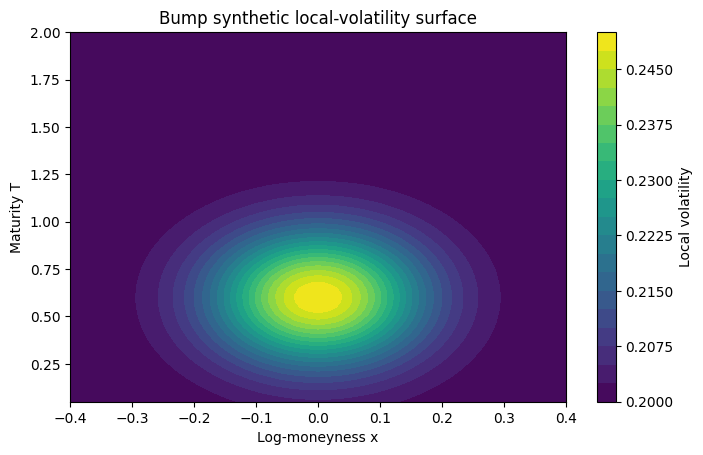

Bump range: 0.2000 to 0.2499


In [6]:
bump_values = bump_surface(
    x_mesh,
    maturity_mesh,
)

plt.figure(figsize=(8, 4.8))
contour = plt.contourf(
    x_plot,
    maturity_plot,
    bump_values,
    levels=20,
)
plt.colorbar(contour, label="Local volatility")
plt.xlabel("Log-moneyness x")
plt.ylabel("Maturity T")
plt.title("Bump synthetic local-volatility surface")
plt.show()

print(
    "Bump range:",
    f"{bump_values.min():.4f}",
    "to",
    f"{bump_values.max():.4f}",
)


## 5. Generate a sparse synthetic option chain

We now choose the smile surface as the true model.

The observed market does not reveal the entire continuous price surface.
Instead, it provides quotes at a finite set of strikes and maturities.

We use six maturities and thirteen log-moneyness values, giving

$$
6\times13=78
$$

synthetic option quotes.


In [7]:
quote_maturities = np.array(
    [0.10, 0.25, 0.50, 1.00, 1.50, 2.00]
)
quote_log_moneyness = np.linspace(
    -0.30,
    0.30,
    13,
)

synthetic_quotes = generate_synthetic_option_data(
    surface_function=smile_surface,
    spot=100.0,
    maturities=quote_maturities,
    log_moneyness_values=quote_log_moneyness,
    rate=0.0,
    dividend_yield=0.0,
    relative_noise=0.005,
    minimum_noise=0.01,
    random_seed=1234,
    number_of_strike_points=301,
    number_of_time_steps=300,
)

print("Number of synthetic quotes:", len(synthetic_quotes))
synthetic_quotes.head(10)


Number of synthetic quotes: 78


,maturity,log_moneyness,forward,strike,true_local_volatility,true_call_price,noise_standard_deviation,noise,observed_call_price,call_lower_bound,call_upper_bound
0,0.1,-0.30,100.0,74.081822,0.229425,25.918212,0.129591,-0.000034,25.918178,25.918178,100.0
1,0.1,-0.25,100.0,77.880078,0.227225,22.120423,0.110602,0.007090,22.127513,22.119922,100.0
2,0.1,-0.20,100.0,81.873075,0.225425,18.132482,0.090662,0.067171,18.199653,18.126925,100.0
3,0.1,-0.15,100.0,86.070798,0.224025,13.973593,0.069868,0.010663,13.984256,13.929202,100.0
4,0.1,-0.10,100.0,90.483742,0.223025,9.768884,0.048844,0.042189,9.811073,9.516258,100.0
5,0.1,-0.05,100.0,95.122942,0.222425,5.871807,0.029359,0.085526,5.957333,4.877058,100.0
6,0.1,0.00,100.0,100.000000,0.222225,2.843901,0.014220,-0.021028,2.822873,0.000000,100.0
7,0.1,0.05,100.0,105.127110,0.222425,1.045679,0.010000,0.009455,1.055134,0.000000,100.0
8,0.1,0.10,100.0,110.517092,0.223025,0.278279,0.010000,-0.016661,0.261617,0.000000,100.0
9,0.1,0.15,100.0,116.183424,0.224025,0.051483,0.010000,0.003437,0.054920,0.000000,100.0


## 6. What the columns mean

The most important columns are:

- `maturity`: option maturity \(T\);
- `log_moneyness`: \(x=\log(K/F(T))\);
- `strike`: corresponding option strike;
- `true_local_volatility`: known synthetic truth;
- `true_call_price`: clean PDE price;
- `observed_call_price`: price after noise is added;
- `noise`: observed price minus true price.

Because this is synthetic data, we know both the hidden truth and the noisy
observation.


In [8]:
summary_columns = [
    "maturity",
    "log_moneyness",
    "strike",
    "true_local_volatility",
    "true_call_price",
    "observed_call_price",
    "noise",
]

synthetic_quotes[summary_columns].describe()


,maturity,log_moneyness,strike,true_local_volatility,true_call_price,observed_call_price,noise
count,78.000000,7.800000e+01,78.000000,78.000000,78.000000,78.000000,78.000000
mean,0.891667,-1.281027e-17,101.759137,0.210298,10.103444,10.106666,0.003223
std,0.687807,1.882938e-01,19.091320,0.008634,8.801835,8.794931,0.063514
min,0.100000,-3.000000e-01,74.081822,0.200074,0.000041,0.000000,-0.197249
25%,0.250000,-1.500000e-01,86.070798,0.203274,2.430245,2.429961,-0.015257
50%,0.750000,0.000000e+00,100.000000,0.207494,7.839282,7.874734,0.002359
75%,1.500000,1.500000e-01,116.183424,0.215971,17.648601,17.702751,0.017966
max,2.000000,3.000000e-01,134.985881,0.229425,27.954349,27.854770,0.174962


## 7. Clean and noisy option prices

Each line below corresponds to one maturity. The solid line is the clean PDE
price and the points are the noisy synthetic market quotes.


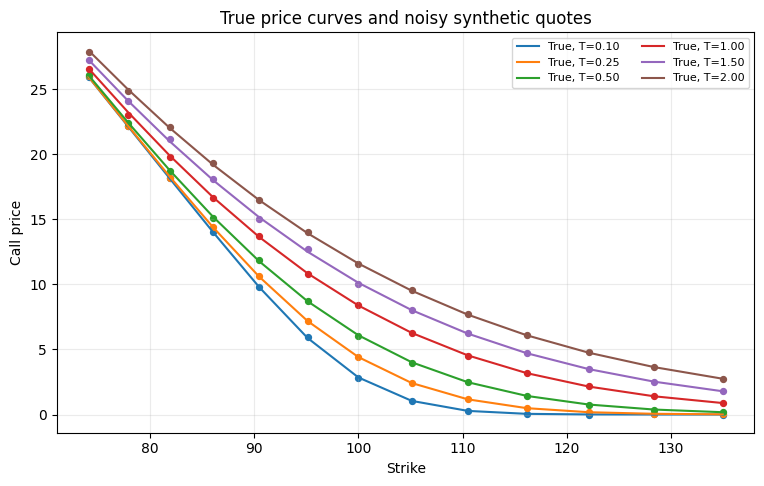

In [9]:
plt.figure(figsize=(9, 5.2))

for maturity in quote_maturities:
    maturity_data = synthetic_quotes[
        np.isclose(
            synthetic_quotes["maturity"],
            maturity,
        )
    ]

    plt.plot(
        maturity_data["strike"],
        maturity_data["true_call_price"],
        label=f"True, T={maturity:.2f}",
    )
    plt.scatter(
        maturity_data["strike"],
        maturity_data["observed_call_price"],
        s=18,
    )

plt.xlabel("Strike")
plt.ylabel("Call price")
plt.title("True price curves and noisy synthetic quotes")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.25)
plt.show()


## 8. Inspect the noise

The noise is deliberately small relative to option prices. Even small price
noise can become important later because raw Dupire differentiates the price
surface.


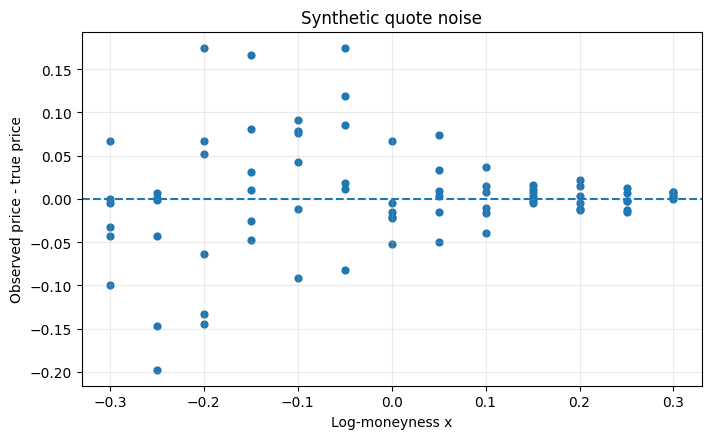

Maximum absolute noise: 0.197249


In [10]:
plt.figure(figsize=(8, 4.6))
plt.scatter(
    synthetic_quotes["log_moneyness"],
    synthetic_quotes["noise"],
    s=24,
)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Log-moneyness x")
plt.ylabel("Observed price - true price")
plt.title("Synthetic quote noise")
plt.grid(alpha=0.25)
plt.show()

print(
    "Maximum absolute noise:",
    f"{synthetic_quotes['noise'].abs().max():.6f}",
)


## 9. Save the synthetic dataset

The CSV is saved inside:

```text
data/synthetic/smile_quotes.csv
```

Later notebooks will load this same dataset for raw Dupire, smoothed Dupire,
and regularised inversion.


In [11]:
output_path = save_synthetic_option_data(
    synthetic_quotes,
    project_root / "data" / "synthetic" / "smile_quotes.csv",
)

print("Saved synthetic data to:")
print(output_path)


Saved synthetic data to:
/mnt/data/dupire_audit/dupire_local_vol_project/data/synthetic/smile_quotes.csv


## Stage 3 result

We now have:

1. three known synthetic local-volatility surfaces;
2. a conversion from \(\sigma(x,T)\) to the \(\sigma(K,T)\) input required by
   the PDE;
3. a sparse synthetic option chain;
4. clean option prices;
5. reproducible noisy observed prices.

The next stage will apply raw and smoothed Dupire to these noisy quotes and
show why direct differentiation is unstable.
